In [1]:
%matplotlib inline
import os, sys

ROOT = os.path.expanduser('~/QIAO0042/models/acv/facemask/')
os.chdir(ROOT)

print('Working dir:', os.getcwd())

Working dir: /scratch-share/QIAO0042/models/acv/facemask


In [1]:
import wandb
import matplotlib.pyplot as plt
from IPython.display import display

WANDB_ENTITY  = '584832452-nanyang-technological-university-singapore'
WANDB_PROJECT = 'face-parsing-unet'

# ── Candidate key names (checked in order) ───────────────────────────────────
_LOSS_CANDIDATES    = ['train/loss', 'train_loss', 'loss']
_VAL_F1_CANDIDATES  = ['val/macro_f1', 'val/f1', 'val_f1', 'val/macro_F1']
_VAL_ACC_CANDIDATES = ['val/acc', 'val_acc', 'val/accuracy']
_LR_CANDIDATES      = ['lr', 'learning_rate', 'train/lr']


def _pick(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None


def fetch_history(run_id):
    api  = wandb.Api()
    path = run_id if '/' in run_id else f'{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}'
    run  = api.run(path)

    df   = run.history(samples=10_000, pandas=True)
    cols = set(df.columns)

    print(f"Run    : {run.name}  ({run.id})  |  state: {run.state}")
    print(f"Columns: {sorted(cols)}")

    loss_col    = _pick(cols, _LOSS_CANDIDATES)
    val_f1_col  = _pick(cols, _VAL_F1_CANDIDATES)
    val_acc_col = _pick(cols, _VAL_ACC_CANDIDATES)
    lr_col      = _pick(cols, _LR_CANDIDATES)

    if loss_col is None:
        raise KeyError(
            f"No loss column found in run '{run.name}'.\n"
            f"  Available columns: {sorted(cols)}\n"
            f"  Searched for: {_LOSS_CANDIDATES}"
        )

    print(f"Mapped : train_loss←'{loss_col}'  "
          f"val_f1←'{val_f1_col}'  "
          f"val_acc←'{val_acc_col}'  "
          f"lr←'{lr_col}'")

    keep = {c for c in [loss_col, val_f1_col, val_acc_col, lr_col] if c}
    sub  = df[list(keep)].dropna(subset=[loss_col])

    history = {'train_loss': sub[loss_col].tolist()}
    history['val_f1']  = sub[val_f1_col].tolist()  if val_f1_col  else None
    history['val_acc'] = sub[val_acc_col].tolist()  if val_acc_col else None
    history['lr']      = sub[lr_col].tolist()       if lr_col      else None

    print(f"Steps  : {len(sub)}")

    config = {k: v for k, v in run.config.items() if not k.startswith('_')}
    return history, config


def list_runs(name_filter=None):
    api  = wandb.Api()
    runs = api.runs(f'{WANDB_ENTITY}/{WANDB_PROJECT}')
    print(f'{"ID":>10}  {"Name":<45}  {"State":>8}  {"Steps":>6}')
    print('-' * 75)
    for r in runs:
        if name_filter and name_filter not in r.name:
            continue
        steps = r.summary.get('_step', '?')
        print(f'{r.id:>10}  {r.name:<45}  {r.state:>8}  {steps!s:>6}')


def plot_curves(histories, labels, title='', save=False):
    """
    Plot training loss and val metric (F1 or accuracy) for one or more runs.
    Uses display(fig) for reliable rendering on remote Jupyter servers.
    Saves to <title>.png when save=True and title is non-empty.
    """
    val_key   = 'val_f1'  if any(h.get('val_f1')  is not None for h in histories) \
           else 'val_acc' if any(h.get('val_acc') is not None for h in histories) \
           else None
    val_label = {'val_f1': 'Val macro-F1', 'val_acc': 'Val Accuracy'}.get(val_key, '')

    n_axes = 2 if val_key else 1
    fig, axes = plt.subplots(1, n_axes, figsize=(6 * n_axes, 4))
    if n_axes == 1:
        axes = [axes]

    colors = plt.cm.tab10.colors

    for i, (hist, lbl) in enumerate(zip(histories, labels)):
        c      = colors[i % len(colors)]
        epochs = range(1, len(hist['train_loss']) + 1)
        axes[0].plot(epochs, hist['train_loss'], color=c, label=lbl)

        if val_key and hist.get(val_key) is not None:
            axes[1].plot(epochs, hist[val_key], color=c, label=lbl)

    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Train Loss')
    axes[0].set_title(f'{title} — Train Loss' if title else 'Train Loss')
    axes[0].legend()

    if n_axes > 1:
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel(val_label)
        axes[1].set_title(f'{title} — {val_label}' if title else val_label)
        axes[1].legend()

    fig.tight_layout()

    if save and title:
        fname = f'{title.replace(" ", "_")}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')

    display(fig)
    plt.close(fig)


print('wandb history utilities ready.')

wandb history utilities ready.


In [2]:
list_runs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/msai/qiao0042/.netrc.


        ID  Name                                              State   Steps
---------------------------------------------------------------------------
  dwcvue93  liteunet_base32_seed42                         finished      79
  9lujzcbk  liteunet_base32_seed42                         finished       9
  fk9ie1p9  liteunet_base32_seed42                         finished      79
  8s0z4pq0  liteunet_base32_seed42_aug2                    finished       ?
  trh43d8g  liteunet_base32_seed42_aug2                    finished      79
  2ehobxi4  liteunet_base32_seed42_aug2_longer             finished     149
  3m6xflfo  liteunet_base32_seed42_aug2_longer2            finished      42
  3901j7zf  liteunet_base32_seed42_aug2_longer3            finished       ?
  53b074vs  liteunet_base32_seed42_aug2_longer3            finished      55
  8ugvg7tj  liteunet_base32_seed42_aug2_longer3            finished       8
  89ammtmq  liteunet_base48_seed42_aug2_longer3            finished      76
  x5cpm27x  

KeyboardInterrupt: 

In [ ]:

hist8, _ = fetch_history('cnzbvy0x')

Run    : unetv2_base23_attn_aspp_ds_drop0.3_ls0.1_e100  (tl7pxb2f)  |  state: finished
Columns: ['_runtime', '_step', '_timestamp', 'epoch', 'lr', 'time/epoch_sec', 'train/loss', 'val/macro_f1']
Mapped : train_loss←'train/loss'  val_f1←'val/macro_f1'  val_acc←'None'  lr←'lr'
Steps  : 100
Run    : unetv2_b16_ema_tta_cutmix_ohem0.7_L40S  (cnzbvy0x)  |  state: finished
Columns: ['_runtime', '_step', '_timestamp', 'ema/decay', 'epoch', 'lr', 'time/epoch_sec', 'train/loss', 'val/macro_f1']
Mapped : train_loss←'train/loss'  val_f1←'val/macro_f1'  val_acc←'None'  lr←'lr'
Steps  : 100


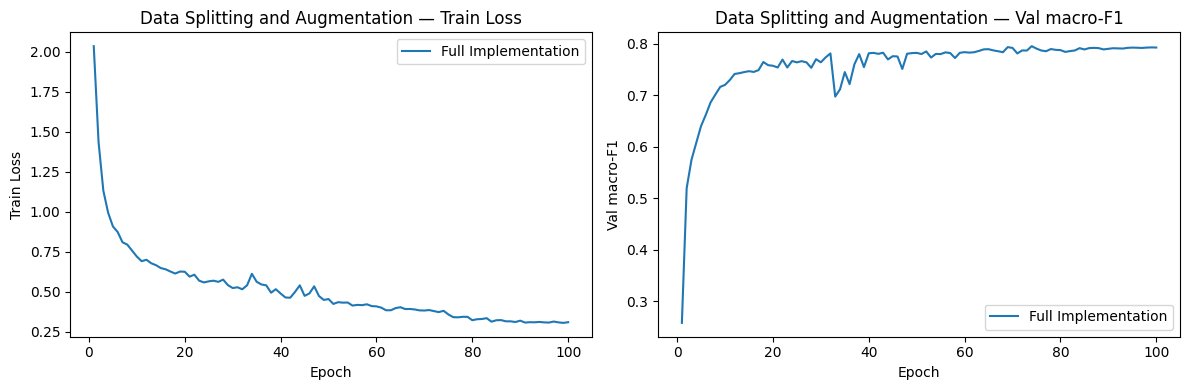

In [ ]:
# Compare: no weight decay (cosine, Section 4) vs two WD values
plot_curves(
    histories=[hist8],
    labels=['Full Implementation'],
    title='Data Splitting and Augmentation'
)

In [ ]:
val_f1 = hist8.get("val_f1")

if val_f1 is None:
    print("No val_f1 found in this run.")
else:
    val_f1_clean = [x for x in val_f1 if x is not None and x == x]  # remove None/NaN
    if not val_f1_clean:
        print("val_f1 exists but has no valid values.")
    else:
        final_val_f1 = val_f1_clean[-1]
        train_loss = hist8.get("train_loss")
        train_loss_clean = [x for x in (train_loss or []) if x is not None and x == x]

        print(f"Final val_f1: {final_val_f1:.6f}")
        if train_loss_clean:
            final_train_loss = train_loss_clean[-1]
            print(f"Final train_loss: {final_train_loss:.6f}")
        else:
            print("train_loss exists but has no valid values.")

Final val_f1: 0.792223
Final train_loss: 0.308890


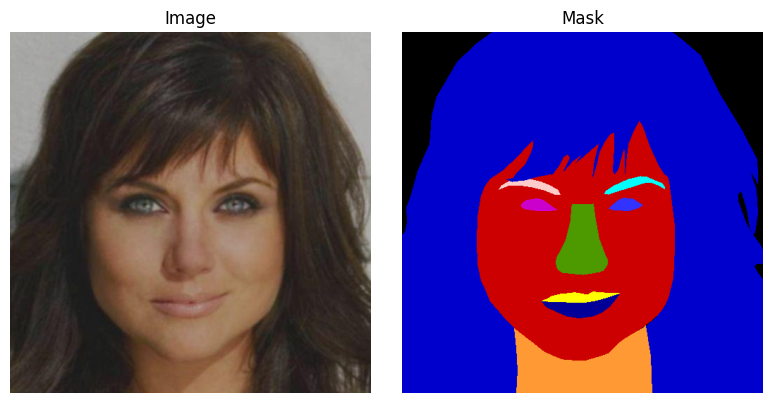

In [ ]:
from PIL import Image
from pathlib import Path

train_dir = Path(globals().get("train_dir", Path(ROOT) / "train"))
if not train_dir.exists():
    raise FileNotFoundError(f"train_dir does not exist: {train_dir}")

images_dir = train_dir / "images"
masks_dir = train_dir / "masks"

img_map = {p.stem: p for p in images_dir.iterdir() if p.is_file()}
mask_map = {p.stem: p for p in masks_dir.iterdir() if p.is_file()}

common_stems = sorted(set(img_map) & set(mask_map))
if not common_stems:
    raise FileNotFoundError(f"No matched image/mask pairs in:\n{images_dir}\n{masks_dir}")

stem = common_stems[0]  # first pair (no augmentation, no random sampling)
img_p = img_map[stem]
mask_p = mask_map[stem]

img = Image.open(img_p).convert("RGB")
mask = Image.open(mask_p)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img)
axes[0].set_title(f"Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="tab20")
axes[1].set_title(f"Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Sample: e0d6be407f224ab6bc3fcba2e762acb0


/tmp/ipykernel_752503/1951073633.py:44: UserWarning: Argument(s) 'value, mask_value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(


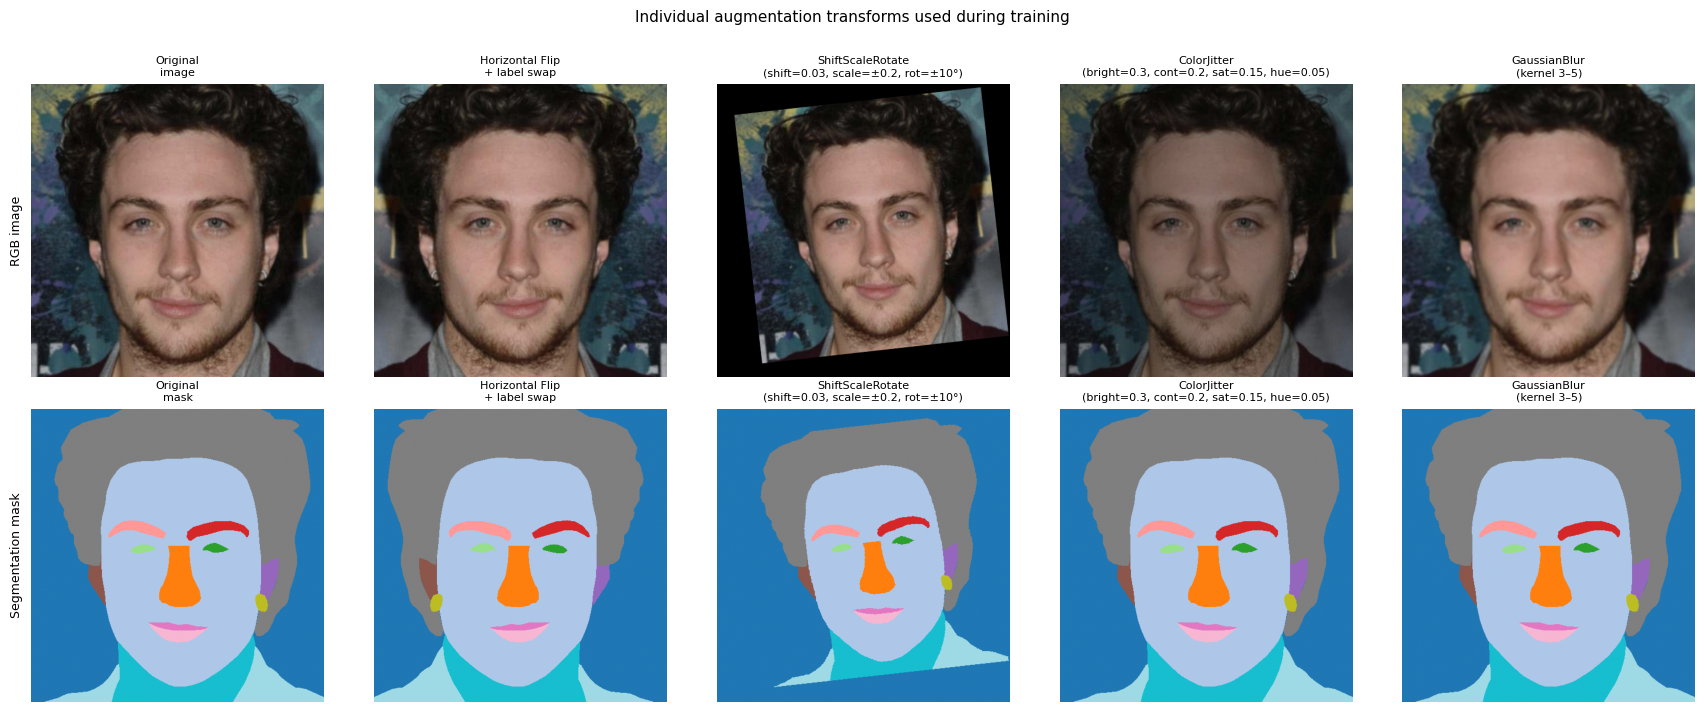

In [3]:

import sys, random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from PIL import Image
from pathlib import Path

sys.path.insert(0, str(Path(ROOT)))
from augment import flip_with_label_swap

# ── Config ───────────────────────────────────────────────────────────────────
SEED = 0   # set None for a different sample each run

# ── Load a sample image/mask pair ────────────────────────────────────────────
train_dir  = Path(ROOT) / "train"
img_map    = {p.stem: p for p in (train_dir / "images").iterdir() if p.is_file()}
mask_map   = {p.stem: p for p in (train_dir / "masks").iterdir()  if p.is_file()}
stems      = sorted(set(img_map) & set(mask_map))

rng   = random.Random(SEED)
stem  = rng.choice(stems)
print(f"Sample: {stem}")

img_orig  = np.array(Image.open(img_map[stem]).convert("RGB"))
mask_orig = np.array(Image.open(mask_map[stem])).astype(np.int64)

# ── Define each augmentation used during training (applied in isolation) ──────
def apply_album(transform, img, mask):
    out = transform(image=img.copy(), mask=mask.copy().astype(np.int32))
    return out["image"], out["mask"].astype(np.int64)

if SEED is not None:
    np.random.seed(SEED)

aug_steps = [
    (
        "Horizontal Flip\n+ label swap",
        *flip_with_label_swap(img_orig.copy(), mask_orig.copy(), p=1.0),
    ),
    (
        "ShiftScaleRotate\n(shift=0.03, scale=±0.2, rot=±10°)",
        *apply_album(
            A.ShiftScaleRotate(
                shift_limit=0.03, scale_limit=0.20, rotate_limit=10,
                border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0, p=1.0,
            ),
            img_orig, mask_orig,
        ),
    ),
    (
        "ColorJitter\n(bright=0.3, cont=0.2, sat=0.15, hue=0.05)",
        *apply_album(
            A.ColorJitter(brightness=0.3, contrast=0.2, saturation=0.15, hue=0.05, p=1.0),
            img_orig, mask_orig,
        ),
    ),
    (
        "GaussianBlur\n(kernel 3–5)",
        *apply_album(
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            img_orig, mask_orig,
        ),
    ),
]

# ── Plot ─────────────────────────────────────────────────────────────────────
n_cols = len(aug_steps) + 1
fig, axes = plt.subplots(2, n_cols, figsize=(3.5 * n_cols, 7))

def show(ax, arr, title, cmap=None):
    ax.imshow(arr, cmap=cmap)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

show(axes[0, 0], img_orig,  "Original\nimage")
show(axes[1, 0], mask_orig, "Original\nmask",  cmap="tab20")

for col, (title, img_aug, mask_aug) in enumerate(aug_steps, start=1):
    show(axes[0, col], img_aug,  title)
    show(axes[1, col], mask_aug, title, cmap="tab20")

# row labels
for row, label in enumerate(["RGB image", "Segmentation mask"]):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=6)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    for spine in axes[row, 0].spines.values():
        spine.set_visible(False)

fig.suptitle("Individual augmentation transforms used during training", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()
